Colloidal solutions containing polymers are of great interest because of the phase behavior observed by tuning the different system parameters. See PhysRevLett.81.4004.pdf. 

The "depletion force" refers to an attractive interaction experienced between colloidal particles in a solution with a nonadsorbing polymer background. Since the attractive force arises from the fact that the polymer molecules are depleted at the surface of the colloids, the force is called the depletion force. The depletion force is well-modeled by the Asakura-Oosawa potential. 

The polymers can be treated as hard spheres with radius of gyration R, diameter 2R. If h, the distance between two colloidal particles, is less than 2R, polymer particles can't enter the vicinity of the colloidal particles, creating a region that is depleted of polymers. This increases the osmotic pressure of the resulting solution and creates a force (an attractive force) that pushes the colloidal particles together.

The effect increases with increasing solution concentration.

https://en.wikipedia.org/wiki/Depletion_force

Doi, Soft Matter

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit
from openmm import Continuous1DFunction, CustomNonbondedForce
import math

%matplotlib inline

In [ ]:
radius1 = 105.0
radius2 = 85.0
 #consider the method used to define this average; there are several to choose from

brush_length = 10.0
brush2=2*brush_length

brush_density=0.09

phi = 1
rdep = 5

h_vals = np.linspace(15.0, 36.0, num=1000)

In [ ]:
def expected_steric_repulsion(steric_prefactor, h):
        """
        Return the steric potential from the Alexander-de Gennes polymer brush model for the given 
        surface-to-surface separations.
        """
        brush2 = 2.0 * brush_length
        
        return (steric_prefactor * np.where(h <= brush2,
                                     28.0 * (np.power(brush2 / h, 0.25) - 1.0)
                                     + 20.0 / 11.0 * (1.0 - np.power(h / brush2, 2.75))
                                     + 12.0 * (h / brush2 - 1.0),
                                     0.0) )

In [ ]:
steric_prefactor = 16*np.pi*(radius1 + radius2)/2*(brush2**2)*(brush_density**(3./2))/35.
potential_vals = expected_steric_repulsion(steric_prefactor, h_vals)
plt.plot(h_vals, potential_vals/2.4777)
plt.ylim(-50, 45)
plt.show()

In [250]:
def get_steric_potential(h_positions, box_length, radius1, radius2, brush_length, brush_density, platform_name="Reference"):
    
    system = openmm.System()
    
    box_length = box_length * unit.nanometer 
    brush_length = brush_length * unit.nanometer
    brush_density = brush_density / unit.nanometer**2
    temperature = 298.0 * unit.kelvin
    radius1 = radius1 * unit.nanometer
    radius2 = radius2 * unit.nanometer
    
    
    system.setDefaultPeriodicBoxVectors([box_length, 0.0, 0.0],
                                        [0.0, box_length, 0.0],
                                        [0.0, 0.0, box_length])
    
    """Set up the basic functional form of the steric potential from the Alexander-de Gennes polymer brush model."""
    steric_potential = CustomNonbondedForce(
        "step(two_l - h) * "
        "steric_prefactor * rs / 2.0 * brush_length * brush_length * ("
        "28.0 * ((two_l / h)^0.25 - 1.0) "
        "+ 20.0 / 11.0 * (1.0 - (h / two_l)^2.75)"
        "+ 12.0 * (h / two_l - 1.0)); "
        "h = r - rs;"
        "rs = radius1 + radius2;"
        "two_l = 2.0 * brush_length"
    )
    # Prefactor is k_B * T * 16 * pi * sigma^(3/2) / 35 (see Hocky paper)
    steric_potential.addGlobalParameter(
        "steric_prefactor",
        (unit.BOLTZMANN_CONSTANT_kB * temperature
         * 16.0 * math.pi * (brush_density**(3 / 2)) / 35.0
         * unit.AVOGADRO_CONSTANT_NA).value_in_unit(unit.kilojoule_per_mole / (unit.nanometer ** 3))
    )
    # Brush length L (see Hocky paper)
    steric_potential.addGlobalParameter("brush_length", brush_length)
    steric_potential.addGlobalParameter("radius1", radius1)
    steric_potential.addGlobalParameter("radius2", radius2)
    
     # Add forces.
    system.addForce(steric_potential)
    #system.addForce(depletion_potential)
    
    # Add particles to the system 
    system.addParticle(mass=1.0)
    steric_potential.addParticle()
    #depletion_potential.addParticle()
    
    system.addParticle(mass=1.0)
    steric_potential.addParticle()
    #depletion_potential.addParticle()
    
    #for force in system.getForces():
     #   print(f"Energy function: {force.getEnergyFunction()}")
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    temperature = 298.0 * unit.kelvin
    dummy_integrator = openmm.LangevinIntegrator(
        temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    #print(f"Using {context.getPlatform().getName()} platform.")
    #if context.getPlatform().getName() == "CUDA":
       # for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
       #     print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    potential_energies = np.zeros(len(h_positions))
    for h_index, h_pos in enumerate(h_positions):

        context.setPositions([[h_pos + radius1 + radius2, 0, 0], [0,0,0]])
        state = context.getState(getEnergy=True)
        
        potential_energies[h_index] = (
            state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
            #/ (unit.BOLTZMANN_CONSTANT_kB * temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies
    #return steric_potential

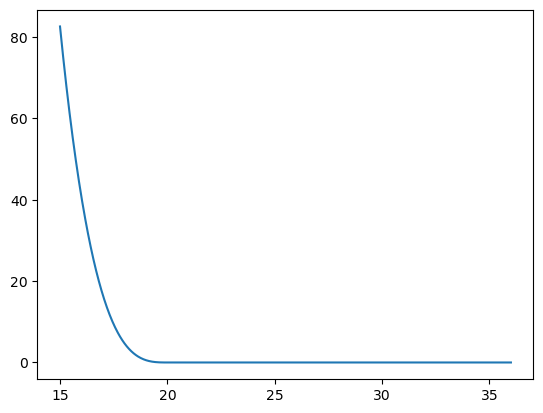

In [251]:
h_positions = np.linspace(15.0, 36.0, num=1000) * unit.nanometer

steric_potentials = get_steric_potential(h_positions, 1000, 105,105, 10, 0.09)

plt.plot(h_positions, steric_potentials)
plt.show()

In [252]:
def expected_AO_potential(r, radius_colloid, brush_length, brush_density, phi, radius_depletant):
    """
    Return the Asakura-Oosawa potential for a colloidal solution in a 
    background of non-adsorbing polymers.

    radius_colloid: radius of the colloid particle
    brush_length: length of polymer brush
    phi: packing fraction of polymer depletants; must be between 0 and 1
    radius_depletant: "radius" of the polymer depletants, if they are approximated as hard spheres
    
    """
    brush_length = brush_length * unit.nanometer
    brush_density = brush_density / unit.nanometer**2
    radius_colloid = radius_colloid * unit.nanometer
    radius_depletant = radius_depletant * unit.nanometer
    temperature = 298.0 * unit.kelvin
    
    #diameters 
    sigma_colloid = ((2 * radius_colloid) + 2*brush_length) #*unit.nanometer

    sigma_depletant = ((2 * radius_depletant) + 2*brush_length) #*unit.nanometer

    # size ratio 
    q = sigma_depletant/sigma_colloid 

    ## this analytical expression only works for q < 0.1547
    
    #surface-to-surface separation
    h = r - 2*radius_colloid #- 2*brush_length
    
    #r = h + sigma_colloid + sigma_depletant
    
    #if sigma_colloid < r <= (sigma_colloid + sigma_depletant):
    if (h <= 2*brush_length and h >0 *unit.nanometer) and (r <= (sigma_colloid + sigma_depletant)):
        
        steric_potential = get_steric_potential([h], 1000, 105,105, 10, 0.09)
        
        '''steric_prefactor = (unit.BOLTZMANN_CONSTANT_kB * temperature
         * 16.0 * math.pi * (brush_density**(3 / 2)) / 35.0
         * unit.AVOGADRO_CONSTANT_NA).value_in_unit(unit.kilojoule_per_mole / (unit.nanometer ** 3))
        
        print(steric_prefactor)
    
        
        steric_potential = (steric_prefactor.value_in_unit(unit.kilojoule_per_mole / (unit.nanometer ** 3))  
                                     * (radius_colloid + radius_colloid)/2*((2*brush_length)**2)
                                     * 28.0 * (np.power(brush_length*2 / h, 0.25) - 1.0)
                                     + 20.0 / 11.0 * (1.0 - np.power(h / brush_length*2, 2.75))
                                     + 12.0 * (h / brush_length*2 - 1.0),
                                     0.0) '''
        
        AO_prefactor = -phi * (1+q)**3/q**3
        term1 = 3*r / (2 * sigma_colloid * (1+q))
        term2 = r**3 / (2 * sigma_colloid**3 *(1+q)**3)

        AO_potential = (AO_prefactor * (1 - term1 + term2)) #.value_in_unit(unit.kilojoule_per_mole)
    
    elif h > 2*brush_length and r <= (sigma_colloid + sigma_depletant):
        
        steric_potential = 0
        
        AO_prefactor = -phi * (1+q)**3/q**3
        term1 = 3*r / (2 * sigma_colloid * (1+q))
        term2 = r**3 / (2 * sigma_colloid**3 *(1+q)**3)

        AO_potential = (AO_prefactor * (1 - term1 + term2)) #.value_in_unit(unit.kilojoule_per_mole)
        
    else:
        steric_potential = 0
        AO_potential = 0 
        
    return steric_potential + AO_potential *2.477
    

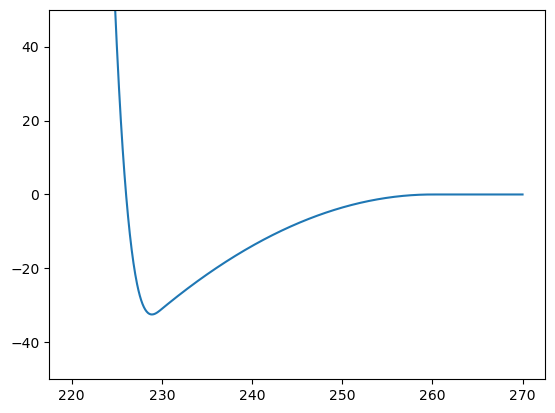

In [254]:
r_vals = np.linspace(220.0, 270.0, num=1000) * unit.nanometer

ao_vals = []

for r in r_vals:
    
    ao = expected_AO_potential(r, radius_colloid = radius_colloid, brush_density=brush_density, brush_length = brush_length, phi = 1, radius_depletant = radius_depletant)

    ao_vals.append(ao) #*2.477) #convert from kT to kj/mol
    
plt.plot(r_vals, ao_vals)
plt.ylim(-50,50)
plt.show()

In [223]:
h_positions = np.linspace(15.0, 36.0, num=1000) * unit.nanometer
radius_colloid = 105.0
radius_depletant = 5.0 #16.0
brush_length = 10.0
brush_density=0.09
box_length = 10.0

steric_potentials = get_steric_potential(h_positions, box_length = box_length, radius1 = radius_colloid, radius2 = radius_colloid, brush_length = brush_length, brush_density = brush_density)


sigma_colloid = ((2 * radius_colloid) + 2*brush_length) *unit.nanometer
sigma_depletant = ((2 * radius_depletant) + 2*brush_length) *unit.nanometer

#r_vals = (h_positions + 2*radius_colloid * unit.nanometer + 2*radius_depletant * unit.nanometer)

r_vals = np.linspace(220.0, 270.0, num=1000) * unit.nanometer

ao_vals = []

for r in r_vals:
    
    ao = expected_AO_potential(r, radius_colloid = radius_colloid, brush_length = brush_length, phi = 1, radius_depletant = radius_depletant)

    ao_vals.append(ao *2.477) #convert from kT to kj/mol
    

plt.plot(h_positions, ao_vals+steric_potentials)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
#plt.ylim(-45, 50)
plt.show()

Energy function: step(two_l - h) * steric_prefactor * rs / 2.0 * brush_length * brush_length * (28.0 * ((two_l / h)^0.25 - 1.0) + 20.0 / 11.0 * (1.0 - (h / two_l)^2.75)+ 12.0 * (h / two_l - 1.0)); h = r - rs;rs = radius1 + radius2;two_l = 2.0 * brush_length
Using Reference platform.


TypeError: expected_AO_potential() missing 1 required positional argument: 'brush_density'

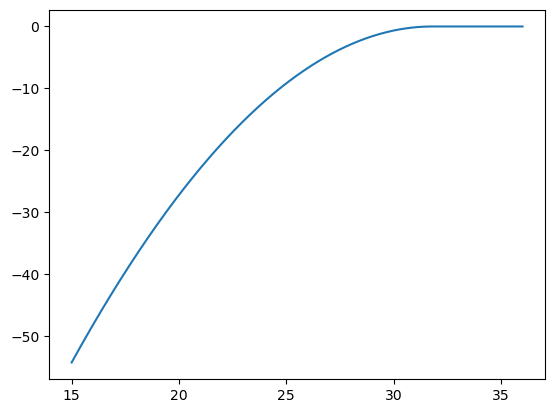

In [162]:
plt.plot(h_positions, ao_vals)
plt.show()

In [194]:
def expected_AO_potential_1(r, radius1, radius2, brush_length, phi, rdep):
    """
    Return the Asakura-Oosawa potential (generalized to asymmetric sphere) for a colloidal solution in a 
    background of non-adsorbing polymers.
    
    h: surface-to-surface particle separation distance
    radius1: radius of first type of colloidal particle
    radius2: radius of second type of colloidal particle
    brush_length: length of polymer brush
    phi: volume fraction of polymer depletants (must be between 0 and 1)
    rdep: radius of polymer depletants
    
    """
    
       # if r <= (sigma_colloid + sigma_depletant):
      #  prefactor = -phi * (1+q)**3/q**3
      #  term1 = 3*r / (2 * sigma_colloid * (1+q))
      #  term2 = r**3 / (2 * sigma_colloid**3 *(1+q)**3)
        
    
    #diameters
    sigmaD1 = 2*brush_length + 2*radius1 
    sigmaD2 = 2*brush_length + 2*radius2
    
    
    rcc = r + radius1 + radius2
    #print(rcc)
    #print(sigmaD1/2 + sigmaD2/2 + 2*rdep)
    
    #h = radius1 + radius2 + r #center-to-center separation distance 
    
    q1 = radius1/rdep #ratio of particle sizes: colloid1 to polymer
    q2 = radius2/rdep ##ratio of particle sizes: colloid2 to polymer
    n = rcc/rdep

    return ( -phi/16 * np.where(rcc <= (sigmaD1/2 + sigmaD2/2 + 2*rdep),
                                    (q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2)),
                                    #(q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2)),
                                    0.0))

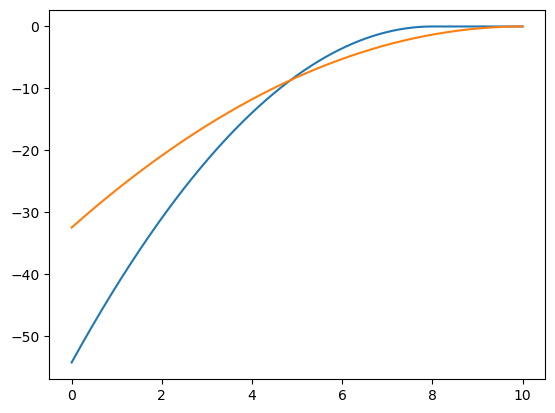

In [198]:
r_vals = np.linspace(0.0, 10.0, num=1000) #* unit.nanometer

ao_vals2 = []

for r in r_vals:
    
    ao = expected_AO_potential_1(r, radius_colloid, radius_colloid, brush_length, 1, radius_depletant)
    
    ao_vals2.append(ao) #*2.477) #convert from kT to kj/mol

plt.plot(r_vals, ao_vals)
plt.plot(r_vals, ao_vals2)
#plt.ylim(-50, 45)
plt.show()

In [158]:
ao_vals2

[-0.0,
 -2.0477734666287075e-06,
 -8.191714977980717e-06,
 -1.8432756201272305e-05,
 -3.277182880369648e-05,
 -5.120986445246663e-05,
 -7.374779481480773e-05,
 -0.00010038655155789534,
 -0.00013112706634897485,
 -0.0001659702708552363,
 -0.00020491709674385825,
 -0.0002479684756821035,
 -0.0002951253393371185,
 -0.0003463886193761397,
 -0.0004017592474664158,
 -0.00046123815527507545,
 -0.0005248262744694107,
 -0.0005925245367165884,
 -0.0006643338736837636,
 -0.000740255217038246,
 -0.0008202894984471349,
 -0.0009044376495776909,
 -0.0009927006020971853,
 -0.0010850792876727002,
 -0.0011815746379715746,
 -0.001282187584660952,
 -0.0013869190594079637,
 -0.0014957699938799663,
 -0.001608741319744013,
 -0.0017258339686673865,
 -0.001847048872317383,
 -0.0019723869623610364,
 -0.002101849170465734,
 -0.0022354364282985936,
 -0.0023731496675267255,
 -0.0025149898198175325,
 -0.002660957816838019,
 -0.0028110545902554946,
 -0.002965281071737275,
 -0.0031236381929503516,
 -0.003286126885562

In [135]:
plt.plot(h_vals, potential_vals+ ao_vals1)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
plt.ylim(-50, 45)
plt.show()

NameError: name 'potential_vals' is not defined

In [ ]:
def get_potentials(h_values, radius_one, radius_two, phi, radius_depletant, brush_length, platform_name="Reference"):
    
    # Set up system.
    system = openmm.System()
    
    # Make system very large so that we do not care about periodic boundaries.
    side_length = 200.0 * (max(h_values) + radius_one.value_in_unit(unit.nanometer) + radius_two.value_in_unit(unit.nanometer)) 
    system.setDefaultPeriodicBoxVectors([side_length, 0.0, 0.0],
                                        [0.0, side_length, 0.0],
                                        [0.0, 0.0, side_length])
    
    depletion_potentials = DepletionPotentialsAlgebraic(phi, depletant_radius, brush_length)
    
    # Add two particles to the system and forces (mass is unimportant for the potential).
    system.addParticle(mass=1.0)
    depletion_potentials.add_particle(radius=radius_one) #, surface_potential=surface_potential_one)
    system.addParticle(mass=1.0)
    depletion_potentials.add_particle(radius=radius_two) #, surface_potential=surface_potential_two)

    # Add forces.
    for potential in depletion_potentials.yield_potentials():
        system.addForce(potential)
        
    for force in system.getForces():
        print(f"Energy function: {force.getEnergyFunction()}")
        print(f"Nonbonded method: {force.getNonbondedMethod()}, Cutoff distance: {force.getCutoffDistance()}")
        assert force.usesPeriodicBoundaryConditions()
        assert not force.getUseLongRangeCorrection()
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    dummy_integrator = openmm.LangevinIntegrator(
        parameters.temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    
    potential_energies = np.zeros(len(h_values))
    for h_index, h_value in enumerate(h_values):
        context.setPositions([[(radius_one + radius_two).value_in_unit(unit.nanometer) + h_value, 0.0, 0.0], [0.0, 0.0, 0.0]])
        state = context.getState(getEnergy=True)
        potential_energies[h_index] = (
            state.getPotentialEnergy()
            / (unit.BOLTZMANN_CONSTANT_kB * parameters.temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies

In [ ]:
potential_vals = get_potentials(h_vals, radius1, radius2, phi, rdept, brush_length, platform_name="Reference")

In [ ]:
ao_exp = expected_AO_potential_1(h_vals, radius1, radius2, brush_length, phi, rdep)

plt.plot(h_vals, ao_exp,  color="k")
plt.plot(h_vals, potential_vals, color='blue', marker="x")
plt.xlabel("h")
plt.ylabel("PE")
plt.ylim(-50, 45)
plt.show()

In [51]:
r_vals

Quantity(value=array([220.        , 220.05005005, 220.1001001 , 220.15015015,
       220.2002002 , 220.25025025, 220.3003003 , 220.35035035,
       220.4004004 , 220.45045045, 220.5005005 , 220.55055055,
       220.6006006 , 220.65065065, 220.7007007 , 220.75075075,
       220.8008008 , 220.85085085, 220.9009009 , 220.95095095,
       221.001001  , 221.05105105, 221.1011011 , 221.15115115,
       221.2012012 , 221.25125125, 221.3013013 , 221.35135135,
       221.4014014 , 221.45145145, 221.5015015 , 221.55155155,
       221.6016016 , 221.65165165, 221.7017017 , 221.75175175,
       221.8018018 , 221.85185185, 221.9019019 , 221.95195195,
       222.002002  , 222.05205205, 222.1021021 , 222.15215215,
       222.2022022 , 222.25225225, 222.3023023 , 222.35235235,
       222.4024024 , 222.45245245, 222.5025025 , 222.55255255,
       222.6026026 , 222.65265265, 222.7027027 , 222.75275275,
       222.8028028 , 222.85285285, 222.9029029 , 222.95295295,
       223.003003  , 223.05305305, 223.1

In [19]:
h_vals = r_vals - (2*105 + 2*16 -20)

steric_prefactor = 16*np.pi*sigma_avg*(brush2**2)*(brush_density**(3./2))/35.
potential_vals = expected_steric_repulsion(steric_prefactor, h_vals)
plt.plot(r_vals, potential_vals)
plt.ylim(-50, 45)
plt.show()

AttributeError: 'int' object has no attribute 'unit'

In [ ]:
plt.plot( potential_vals + ao_vals)
plt.show()

In [ ]:
h_vals = np.linspace(15.0, 36.0, num=1000)


ao_vals1 = []

for h in h_vals:
    
    ao = expected_AO_potential_1(h, radius1, radius1, brush_length, 0.05, 5)

    ao_vals1.append(ao)
    
plt.plot(h_vals, ao_vals1)
#plt.plot(h_vals, potential_vals)
#plt.plot(h_vals, potential_vals+ ao_vals)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
#plt.ylim(-50, 45)
plt.show()

In [ ]:
potential_vals